In [1]:
import os
import re
import warnings
import umap
import nltk
nltk.download('punkt_tab')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from __future__ import annotations
from dotenv import load_dotenv
from pathlib import Path
from typing import Tuple, List, Optional, Dict
from llama_index.core import SimpleDirectoryReader
from llama_index.core.node_parser import (
    SemanticSplitterNodeParser,
    MarkdownNodeParser,
)
from llama_index.core.schema import TextNode, BaseNode
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.core.node_parser import TokenTextSplitter, SentenceSplitter
from llama_index.core import SimpleDirectoryReader
from nltk.tokenize import sent_tokenize
from transformers import AutoTokenizer
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.spatial.distance import cosine
from scipy.cluster import hierarchy
from scipy.spatial.distance import pdist
from groq import Groq
from scipy.cluster.hierarchy import dendrogram, linkage

/home/neeraj/Projects/pdf_to_markdown/pdf_to_md_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt_tab to /home/neeraj/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
HUGGING_FACE_TOKEN = os.getenv("HUGGING_FACE_TOKEN")

In [4]:
doc_path = "../create_markdown/data/processed_markdown/karnatakastartup/"
doc_ids = ["4d208001-5620-4053-b359-a734e114769a", "5cd83495-17ab-4245-8f08-78d95d27871f"]
doc_paths = [f"{doc_path}{doc_id}.md" for doc_id in doc_ids]
output_dir = "../../data/chunks/"

In [5]:
documents = SimpleDirectoryReader(input_files=doc_paths).load_data() # how many documents at once it can read.

In [6]:
# Tokenizer for Llama 3.1/3.3 70B (best match for Groq's Llama-3.3-70B-Versatile)
tokenizer = AutoTokenizer.from_pretrained(
                                            "meta-llama/Meta-Llama-3.1-70B-Instruct",
                                            token=HUGGING_FACE_TOKEN
                                        )

def llama_tokenizer(text: str) -> List[int]:
    return tokenizer.encode(text, add_special_tokens=False)

# Embedding model
embed_model = HuggingFaceEmbedding("BAAI/bge-small-en-v1.5")

# ─── Helper: Get token count ─────────────────────────────────────────────
def token_count(text: str) -> int:
    return len(llama_tokenizer(text))

# ─── Helper: Process one doc & save nodes ────────────────────────────────
def process_doc(md_path: Path, parser, exp_name: str):
    docs = SimpleDirectoryReader(input_files=[md_path]).load_data()
    if not docs:
        return []

    # Add custom metadata (from your scrape)
    for doc in docs:
        doc.metadata["source_file"] = md_path.name
        doc.metadata["doc_id"] = md_path.split("/")[-1].split(".")[0]
        # Add URL if you have it stored

    nodes = parser.get_nodes_from_documents(docs)
    
    # Save stats
    stats = {
        "file": md_path.name,
        "num_nodes": len(nodes),
        "avg_tokens": np.mean([token_count(n.text) for n in nodes]) if nodes else 0,
        "min_tokens": min([token_count(n.text) for n in nodes]) if nodes else 0,
        "max_tokens": max([token_count(n.text) for n in nodes]) if nodes else 0,
    }
    print(f"{exp_name} - {md_path.name}: {stats}")
    
    # Optional: save nodes text for inspection
    with open(output_dir / f"{exp_name}_{md_path.stem}.txt", "w") as f:
        for i, node in enumerate(nodes):
            f.write(f"--- Chunk {i+1} ({token_count(node.text)} tokens) ---\n")
            f.write(node.text + "\n\n")
    
    return nodes

2026-03-12 09:13:41,023 - INFO - Load pretrained SentenceTransformer: BAAI/bge-small-en-v1.5
2026-03-12 09:13:44,865 - INFO - 2 prompts are loaded, with the keys: ['query', 'text']


In [7]:
# Option A: Token-based (counts actual tokens using tiktoken or similar)
token_splitter = TokenTextSplitter(
    chunk_size=512,           # target chunk size in tokens
    chunk_overlap=64,         # overlap between chunks
    separator=" ",            # fallback separator
    backup_separators=["\n", ".", "!", "?", " ", ""],
)

# Usage
text = """Your long document text here..."""

nodes = token_splitter.get_nodes_from_documents(
    documents=[docs for docs in documents]
)

print(f"Created {len(nodes)} chunks")
for i, node in enumerate(nodes[:3]):
    print(f"Chunk {i+1}: {node.text}...")

Created 19 chunks
Chunk 1: [TOC]

Startup Karnataka[ಕ](https://www.missionstartupkarnataka.org/karnataka-startup-cell?karnataka-startup-cell)* [Startup Directory](https://www.missionstartupkarnataka.org/directory/startup)
* [Startup Kit](https://www.missionstartupkarnataka.org/karnataka-startup-cell?karnataka-startup-cell) Startup Kit

	* [Startup Guide](https://www.missionstartupkarnataka.org/startup-guide)
	* [Policy and Schemes](https://www.missionstartupkarnataka.org/policies)
	* [Incentives](https://www.missionstartupkarnataka.org/incentives)
	* [Karnataka Startup Cell](https://www.missionstartupkarnataka.org/karnataka-startup-cell)
	* [K\-Tech Hub](https://www.missionstartupkarnataka.org/innovation-hub/k-tech-hub)
	* [Booster Kit](https://www.missionstartupkarnataka.org/booster-kit)
	* [Academia](https://www.missionstartupkarnataka.org/academia)
	* [IP facilitation centre](https://www.missionstartupkarnataka.org/ip-facilitation-centres)
	* [Browse startups](https://www.missionsta

In [8]:
# Option B: Simple character-based
char_splitter = SentenceSplitter(
    chunk_size=1024,          # characters
    chunk_overlap=150,
    paragraph_separator="\n\n",
    secondary_chunking_regex=r"[.!?]\s+",
)

# or char splitter
nodes_char = char_splitter.get_nodes_from_documents(
    documents=[docs for docs in documents]
)

print(f"Created {len(nodes_char)} chunks")
for i, node in enumerate(nodes_char[:3]):
    print(f"Chunk {i+1}: {node.text}...")

# without custom tokenizer length of text is considered by length of characters.

Created 10 chunks
Chunk 1: [TOC]

Startup Karnataka[ಕ](https://www.missionstartupkarnataka.org/karnataka-startup-cell?karnataka-startup-cell)* [Startup Directory](https://www.missionstartupkarnataka.org/directory/startup)
* [Startup Kit](https://www.missionstartupkarnataka.org/karnataka-startup-cell?karnataka-startup-cell) Startup Kit

	* [Startup Guide](https://www.missionstartupkarnataka.org/startup-guide)
	* [Policy and Schemes](https://www.missionstartupkarnataka.org/policies)
	* [Incentives](https://www.missionstartupkarnataka.org/incentives)
	* [Karnataka Startup Cell](https://www.missionstartupkarnataka.org/karnataka-startup-cell)
	* [K\-Tech Hub](https://www.missionstartupkarnataka.org/innovation-hub/k-tech-hub)
	* [Booster Kit](https://www.missionstartupkarnataka.org/booster-kit)
	* [Academia](https://www.missionstartupkarnataka.org/academia)
	* [IP facilitation centre](https://www.missionstartupkarnataka.org/ip-facilitation-centres)
	* [Browse startups](https://www.missionsta

In [9]:
recursive_splitter = SentenceSplitter(
    chunk_size=1024,                # characters or approx tokens
    chunk_overlap=150,
    # These are tried in order (best practice)
    paragraph_separator="\n\n",   # first try large paragraphs
    secondary_chunking_regex=r"[.!?]\s+", 
    # You can also set tokenizer if you want real token counting
    tokenizer=lambda text: text.split(),  # simple word splitter
    # or use real tokenizer:
    # from llama_index.core.utils import get_tiktoken_tokenizer
    # tokenizer=get_tiktoken_tokenizer("gpt-4"),
)

# Usage is the same
nodes1 = recursive_splitter.get_nodes_from_documents(documents=[docs for docs in documents])

print(f"Created {len(nodes1)} chunks")
for i, node in enumerate(nodes1[:3]):
    print(f"Chunk {i+1}: {node.text}...")
# with custom tokenizer len of text is taken from length of words

Created 3 chunks
Chunk 1: [TOC]

Startup Karnataka[ಕ](https://www.missionstartupkarnataka.org/karnataka-startup-cell?karnataka-startup-cell)* [Startup Directory](https://www.missionstartupkarnataka.org/directory/startup)
* [Startup Kit](https://www.missionstartupkarnataka.org/karnataka-startup-cell?karnataka-startup-cell) Startup Kit

	* [Startup Guide](https://www.missionstartupkarnataka.org/startup-guide)
	* [Policy and Schemes](https://www.missionstartupkarnataka.org/policies)
	* [Incentives](https://www.missionstartupkarnataka.org/incentives)
	* [Karnataka Startup Cell](https://www.missionstartupkarnataka.org/karnataka-startup-cell)
	* [K\-Tech Hub](https://www.missionstartupkarnataka.org/innovation-hub/k-tech-hub)
	* [Booster Kit](https://www.missionstartupkarnataka.org/booster-kit)
	* [Academia](https://www.missionstartupkarnataka.org/academia)
	* [IP facilitation centre](https://www.missionstartupkarnataka.org/ip-facilitation-centres)
	* [Browse startups](https://www.missionstar

In [10]:
print("Full text length (characters):", len(documents[1].text))
print("Full text length (words):     ", len(documents[1].text.split()))
print("Number of double newlines:    ", documents[1].text.count("\n\n"))
print("Number of triple newlines:    ", documents[1].text.count("\n\n\n"))

Full text length (characters): 16978
Full text length (words):      1381
Number of double newlines:     76
Number of triple newlines:     0


Why to use regex based sentence splitter over LlamaIndex SentenceSplitter

- Semantic breakpoint logic wants as many candidate split points as possible early on
    - You want lots of small sentences so the cosine-distance / percentile method can find fine-grained topic shifts.
    - If you feed large paragraphs into the semantic step, you lose resolution which leads to worse breakpoints.

- Paragraph preservation is less important here
    - The semantic merging step will automatically group semantically similar sentences back together (even across original paragraphs).
    - Forcing paragraph integrity early can actually hurt when a topic change happens mid-paragraph.
Cost & simplicity

- No need to pull in the full LlamaIndex dependency chain just for splitting if you're not using the rest of their ingestion/indexing.
    - Pure regex = zero model loading = fastest cold-start.

- Community patterns in recent semantic chunking guides (2024–2025)
    Most implementations (LangChain SemanticChunker, custom Kamradt-style, Chroma/LlamaIndex SemanticSplitterNodeParser internals) start with sentence splitting via regex or lightweight method (often NLTK punkt if accuracy matters more than speed).
    They rarely use full SentenceSplitter with paragraph preference because it coarsens the candidates too much.

In [11]:
# regex based implementation
def split_text_into_segments(
    text: str,
    splitter_type: str = "sentence",
    min_length: int = 30       # slightly higher helps avoid fragments
) -> List[str]:
    if not text.strip():
        raise ValueError("Input text is empty.")

    if splitter_type == "sentence":
        # Improved English-aware regex (avoids most common false splits)
        pattern = r'(?<!\w\.\w.)(?<![A-Z][a-z]\.)(?<=\.|\?|\!|\:|\;)\s+(?=[A-Z"“])'
        segments = re.split(pattern, text)
        
        # Alternative even stricter variant (used by many semantic pipelines)
        # pattern = r'(?<!\w\.\w.)(?<![A-Z][a-z]\.)(?<=\.|\?|\!)\s'
        
    else:
        raise ValueError(f"Unsupported splitter_type: {splitter_type}")

    segments = [s.strip() for s in segments if len(s.strip()) >= min_length]
    
    if not segments:
        raise ValueError("No valid segments after splitting.")
    
    return segments

In [12]:
# nltk punkt based implementation

try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)  # Downloads ~2–3 MB model if missing

def split_text_into_segments_nltk(
    text: str,
    splitter_type: str = "sentence",
    min_length: int = 30,          # increased a bit — Punkt often leaves short fragments
    language: str = "english"      # can be 'english', 'french', 'german', etc. if needed
) -> List[str]:
    """
    Splits input text into small segments (sentences) using NLTK's Punkt tokenizer.
    
    Args:
        text: Full input text.
        splitter_type: Currently only 'sentence' is supported (Punkt-based).
        min_length: Minimum character length to keep a segment (filters noise/fragments).
        language: Language code for Punkt model (default: 'english').
    
    Returns:
        List of cleaned sentence segments.
    
    Raises:
        ValueError: If text is empty or no valid segments remain.
        ImportError: If NLTK or punkt is not available.
    """
    if not text.strip():
        raise ValueError("Input text is empty.")
    
    if splitter_type != "sentence":
        raise ValueError(f"Unsupported splitter_type: {splitter_type}. Only 'sentence' (Punkt) is implemented here.")
    
    try:
        # Use NLTK's sent_tokenize — it returns a list of sentences
        segments = sent_tokenize(text, language=language)
    except Exception as e:
        raise RuntimeError(f"NLTK sent_tokenize failed: {e}. Make sure 'punkt' is downloaded.")
    
    # Clean and filter short/empty segments
    segments = [s.strip() for s in segments if len(s.strip()) >= min_length]
    
    if not segments:
        raise ValueError("No valid segments after splitting and filtering.")
    
    return segments


# ────────────────────────────────────────────────
# Example usage & comparison
# ────────────────────────────────────────────────

if __name__ == "__main__":
    sample_text = """
    Dr. Smith said: "This is a test... or is it?" He continued, i.e. went on.
    Version 3.14 released on Jan. 1, 2025. U.S.A. is big. Etc. etc.
    What about Mr. John? Or Mrs. Jane? It's tricky!
    """

    try:
        # Your original regex style (for comparison)
        import re
        regex_segments = re.split(
            r'(?<!\w\.\w.)(?<![A-Z][a-z]\.)(?<=\.|\?|\!)\s',
            sample_text
        )
        regex_segments = [s.strip() for s in regex_segments if len(s.strip()) >= 30]
        print("Regex segments:")
        for i, s in enumerate(regex_segments, 1):
            print(f"{i}. {s[:80]}...")

        print("\n" + "="*60 + "\n")

        # New Punkt version
        punkt_segments = split_text_into_segments(sample_text, min_length=30)
        print("Punkt segments:")
        for i, s in enumerate(punkt_segments, 1):
            print(f"{i}. {s[:80]}...")

    except Exception as e:
        print(f"Error: {e}")

Regex segments:
1. Dr. Smith said: "This is a test......
2. or is it?" He continued, i.e. went on....


Punkt segments:
1. "This is a test... or is it?" He continued, i.e. went on....
2. Version 3.14 released on Jan. 1, 2025....


In [13]:
def embed_segments(
    segments: List[str],
    model_name: str = "all-MiniLM-L6-v2"
) -> np.ndarray:
    """
    Embeds a list of text segments using a sentence-transformer model.
    
    Args:
        segments: List of text segments.
        model_name: Hugging Face sentence-transformers model.
    
    Returns:
        Numpy array of embeddings (shape: n_segments x embedding_dim).
    
    Raises:
        RuntimeError: If embedding fails (e.g., model load issue).
    """
    try:
        # or use direct from sentence_transformers import SentenceTransformer
        # embeddings = model.encode(segments, batch_size=32, show_progress_bar=True, normalize_embeddings=True)
        embed_model = HuggingFaceEmbedding(
                model_name="sentence-transformers/all-MiniLM-L6-v2"
            )
        embeddings_list = embed_model.get_text_embedding_batch(segments, show_progress=True)
        embeddings = np.array(embeddings_list)
        return embeddings
    except Exception as e:
        raise RuntimeError(f"Embedding failed: {e}")

In [14]:
def get_breakpoints(
    embeddings: np.ndarray,
    threshold: float = 0.95
) -> np.ndarray:
    """
    Finds indices of breakpoints in a sequence of embeddings based on cosine distance.
    Breakpoint if distance between consecutive embeddings >= percentile threshold.
    
    Args:
        embeddings: Array of embeddings (n x dim).
        threshold: Percentile (0-1) for distance cutoff (e.g., 0.95 = 95th percentile).
    
    Returns:
        Array of breakpoint indices (0-based, relative to start=0).
    """
    if len(embeddings) < 2:
        return np.array([])
    
    cdists = np.array([cosine(embeddings[i], embeddings[i-1]) for i in range(1, len(embeddings))])
    
    if len(cdists) == 0:
        return np.array([])
    
    dist_threshold = np.percentile(cdists, 100 * threshold)
    breakpoint_indices = np.argwhere(cdists >= dist_threshold).ravel()  # indices of the SECOND element in pair
    
    return breakpoint_indices

In [15]:
def build_semantic_chunks(
    segments: List[str],
    embeddings: np.ndarray,
    length_threshold: int = 1000,
    distance_threshold: float = 0.95
) -> Tuple[List[str], List[np.ndarray]]:
    """
    Recursively builds semantic chunks by detecting breakpoints and merging segments.
    Recursion stops when chunk length < length_threshold.
    
    Args:
        segments: List of small segments.
        embeddings: Corresponding embeddings.
        length_threshold: Char length above which to recurse for more breaks.
        distance_threshold: Percentile for breakpoint detection.
    
    Returns:
        List of chunk texts, List of average embeddings per chunk.
    """
    def get_text_length(group: List[str]) -> int:
        return sum(len(s) for s in group)
    
    stack = [(0, len(segments))]
    all_breakpoints = set([0, len(segments)])  # include boundaries
    
    while stack:
        start, end = stack.pop()
        window_emb = embeddings[start:end]
        bps_rel = get_breakpoints(window_emb, distance_threshold)
        bps_abs = bps_rel + start
        
        updated_bps = np.concatenate(([start - 1], bps_abs, [end - 1]))
        updated_bps = np.unique(updated_bps)  # avoid duplicates
        
        prev = start
        for bp in updated_bps[1:]:
            chunk_segs = segments[prev : bp + 1]
            chunk_len = get_text_length(chunk_segs)
            
            if len(chunk_segs) > 2 and chunk_len >= length_threshold:
                stack.append((prev, bp + 1))
            else:
                all_breakpoints.add(bp + 1)  # end of chunk
            
            prev = bp + 1
    
    sorted_bps = sorted(all_breakpoints)
    chunks, chunk_embs = [], []
    
    for i in range(len(sorted_bps) - 1):
        start, end = sorted_bps[i], sorted_bps[i + 1]
        chunk_text = " ".join(segments[start:end])
        chunk_emb = np.mean(embeddings[start:end], axis=0)  # average embedding
        chunks.append(chunk_text)
        chunk_embs.append(chunk_emb)
    
    return chunks, np.array(chunk_embs)

In [16]:
def reduce_dimensions_umap(
    embeddings: np.ndarray,
    n_components: int = 2,
    n_neighbors: int = 5,
    min_dist: float = 0.0,
    metric: str = "cosine",
    random_state: int = 42
) -> np.ndarray:
    """
    Reduces high-dimensional embeddings using UMAP.
    
    Args:
        embeddings: Input embeddings.
        n_components: Target dimensions (2 or higher).
        ... other UMAP params.
    
    Returns:
        Reduced embeddings.
    
    Raises:
        ValueError: If input invalid.
    """
    if embeddings.ndim != 2 or embeddings.shape[0] < 2:
        raise ValueError("Embeddings must be 2D with at least 2 samples.")
    
    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        n_components=n_components,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state
    )
    reduced = reducer.fit_transform(embeddings)
    return reduced

In [20]:
def cluster_semantic_chunks(
    reduced_embeddings: np.ndarray,
    n_clusters: int = 8,
    linkage_method: str = "average"
) -> np.ndarray:
    """
    Performs hierarchical clustering on reduced embeddings and cuts into n_clusters.
    
    Args:
        reduced_embeddings: UMAP-reduced embeddings.
        n_clusters: Desired number of clusters.
        linkage_method: 'average', 'single', 'complete', etc.
    
    Returns:
        Array of cluster labels (length = n_chunks).
    """
    if reduced_embeddings.shape[0] < n_clusters:
        raise ValueError("Too few samples for requested n_clusters.")
    
    dist_matrix = pdist(reduced_embeddings, metric="euclidean")
    linkage_matrix = hierarchy.linkage(dist_matrix, method=linkage_method, optimal_ordering=True)
    labels = hierarchy.cut_tree(linkage_matrix, n_clusters=n_clusters).ravel()
    
    return labels

In [21]:
def label_clusters(
    chunks: List[str],
    cluster_labels: np.ndarray,
    groq_api_key: Optional[str] = None,
    model_name: str = "llama-3.1-8b-instant",   # fast & cheap; alternatives: "llama-3.1-70b-versatile", "mixtral-8x7b-32768", "llama3-groq-70b-8192-tool-use-preview"
    max_tokens: int = 20,
    temperature: float = 0.3
) -> Dict[int, str]:
    """
    Labels clusters using Groq API + Llama model to generate short summaries.
    
    Each cluster gets a concise label (aiming for <10 words).
    
    Args:
        chunks: List of chunk texts.
        cluster_labels: numpy array of cluster ids (same length as chunks).
        groq_api_key: Groq API key (falls back to os.environ["GROQ_API_KEY"]).
        model_name: Groq model ID (check https://console.groq.com/docs/models for latest).
        max_tokens: Max tokens in generated label (keep short).
        temperature: Creativity (lower = more deterministic).
    
    Returns:
        Dict {cluster_id: "short summary label"}
    
    Raises:
        ValueError: If no API key found.
        RuntimeError: If Groq call fails.
    """
    api_key = groq_api_key or os.environ.get("GROQ_API_KEY")
    if not api_key:
        raise ValueError("GROQ_API_KEY not provided and not found in environment variables.")
    
    client = Groq(api_key=api_key)
    
    unique_clusters = np.unique(cluster_labels)
    cluster_texts = {c: [] for c in unique_clusters}
    
    for chunk, lbl in zip(chunks, cluster_labels):
        cluster_texts[lbl].append(chunk)
    
    labels = {}
    for cluster_id, texts in cluster_texts.items():
        # Combine first few chunks (truncate to avoid token explosion)
        combined_text = " ".join(texts[:4])[:1500]  # rough limit
        
        if not combined_text.strip():
            labels[cluster_id] = f"Cluster {cluster_id} (empty)"
            continue
        
        prompt = f"""Summarize the following text in ONE short phrase (max 8 words):
                    Focus on the main topic or theme.
                    Text:
                    {combined_text}

                    Summary:"""
        
        try:
            response = client.chat.completions.create(
                messages=[
                    {"role": "user", "content": prompt}
                ],
                model=model_name,
                max_tokens=max_tokens,
                temperature=temperature,
                top_p=0.9,
            )
            label = response.choices[0].message.content.strip()
            # Clean up common artifacts
            label = label.replace("Summary:", "").strip().rstrip(".")
            if len(label.split()) > 12:  # fallback if too long
                label = label[:100] + "..."
        except Exception as e:
            label = f"Cluster {cluster_id} (Groq error: {str(e)[:60]})"
        
        labels[cluster_id] = label
    
    return labels

In [22]:
def plot_clusters(
    reduced: np.ndarray,
    cluster_labels: np.ndarray,
    cluster_names: Optional[Dict[int, str]] = None,
    title: str = "Semantic Chunks in UMAP Space",
    figsize: tuple = (14, 7),
    point_size: int = 60
):
    """
    Plots UMAP scatter + dendrogram with safe label handling.
    """
    if reduced.shape[1] != 2:
        raise ValueError("reduced must be 2D (n_components=2)")
    
    n_samples = len(reduced)
    unique_clusters = np.unique(cluster_labels)
    n_clusters = len(unique_clusters)
    
    if n_samples < 2:
        print("Too few samples to cluster/plot meaningfully.")
        return
    
    cmap_name = "tab10" if n_clusters <= 10 else "tab20" if n_clusters <= 20 else "hsv"
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, gridspec_kw={'width_ratios': [3, 2]})
    
    # ── UMAP Scatter ─────────────────────────────────────────────
    scatter = ax1.scatter(
        reduced[:, 0], reduced[:, 1],
        c=cluster_labels,
        cmap=cmap_name,
        s=point_size,
        alpha=0.85,
        edgecolor='none'
    )
    plt.colorbar(scatter, ax=ax1, label="Cluster ID", shrink=0.7)
    
    # Annotate cluster names at median positions
    for cid in unique_clusters:
        mask = cluster_labels == cid
        if mask.sum() == 0:
            continue
        med_x, med_y = np.median(reduced[mask], axis=0)
        text = cluster_names.get(cid, f"Cluster {cid}") if cluster_names else f"{cid}"
        ax1.text(med_x, med_y, text, fontsize=9, fontweight='bold',
                 ha='center', va='center', color='black',
                 bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=2))
    
    ax1.set_title("UMAP Projection of Chunks")
    ax1.set_xlabel("UMAP 1")
    ax1.set_ylabel("UMAP 2")
    ax1.grid(True, alpha=0.25, linestyle=':')
    
    # ── Dendrogram ───────────────────────────────────────────────
    Z = linkage(reduced, method='average', metric='euclidean')
    
    # Do NOT pass labels= here — let SciPy use numeric leaf labels (0..n-1)
    dendrogram(
        Z,
        ax=ax2,
        orientation='right',
        leaf_rotation=0,
        leaf_font_size=9,
        color_threshold=0,
        above_threshold_color='lightgray',
        no_labels=False  # show default numeric labels
    )
    
    # Safely rename y-tick labels AFTER drawing (maps original leaf indices)
    if cluster_names:
        yticks = ax2.get_yticks()
        yticklabels = ax2.get_yticklabels()
        
        new_labels = []
        for lbl in yticklabels:
            try:
                leaf_idx = int(lbl.get_text())  # default SciPy labels are str(0), str(1), ...
                # Map leaf index → cluster label (approximate via cluster_labels[leaf_idx])
                cluster_id = cluster_labels[leaf_idx]
                new_text = cluster_names.get(cluster_id, f"{cluster_id}")
            except (ValueError, IndexError):
                new_text = lbl.get_text()  # fallback to original
            
            new_labels.append(new_text)
        
        ax2.set_yticklabels(new_labels)
    
    ax2.set_title("Hierarchical Dendrogram")
    ax2.set_xlabel("Distance")
    
    fig.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [23]:
# Example usage (put it all together)
def execute_semantic_clustering_chunking(doc: str):
    try:
        segments = split_text_into_segments(doc)
        embeddings = embed_segments(segments)
        
        chunks, chunk_embs = build_semantic_chunks(
            segments, embeddings, length_threshold=500, distance_threshold=0.92
        )
        print(f"Found {len(chunks)} semantic chunks.")
        
        reduced = reduce_dimensions_umap(chunk_embs, n_components=2)
        
        labels = cluster_semantic_chunks(reduced, n_clusters=6)
        cluster_labels_dict = label_clusters(
                                                chunks=chunks,
                                                cluster_labels=labels,
                                                groq_api_key=GROQ_API_KEY,
                                                model_name="llama-3.1-8b-instant"
                                            )
        
        print("Generated Cluster Summaries:")
        for cluster_id, summary in sorted(cluster_labels_dict.items()):
            print(f"  Cluster {cluster_id}: {summary}")
        
        # Optional: visualize reduced embeddings colored by cluster
        plot_clusters(
            reduced=reduced,
            cluster_labels=labels,
            cluster_names=cluster_labels_dict
        )
    except Exception as e:
        print(f"Pipeline error: {e}")

2026-03-12 09:23:08,729 - INFO - Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


2026-03-12 09:23:12,139 - INFO - 2 prompts are loaded, with the keys: ['query', 'text']
Generating embeddings: 100%|██████████| 15/15 [00:01<00:00, 10.17it/s]
/home/neeraj/Projects/pdf_to_markdown/pdf_to_md_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Found 7 semantic chunks.


2026-03-12 09:23:26,769 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-12 09:23:26,933 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-12 09:23:27,053 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-12 09:23:27,177 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-12 09:23:27,379 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-12 09:23:27,505 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Generated Cluster Summaries:
  Cluster 0: Karnataka startup policy and support resources
  Cluster 1: BWSSB develops real-time sewage monitoring system
  Cluster 2: Early detection of plant diseases and pests
  Cluster 3: Health services through community engagement
  Cluster 4: Reducing Bengaluru traffic congestion through innovation
  Cluster 5: Water Conservation in Karnataka initiatives


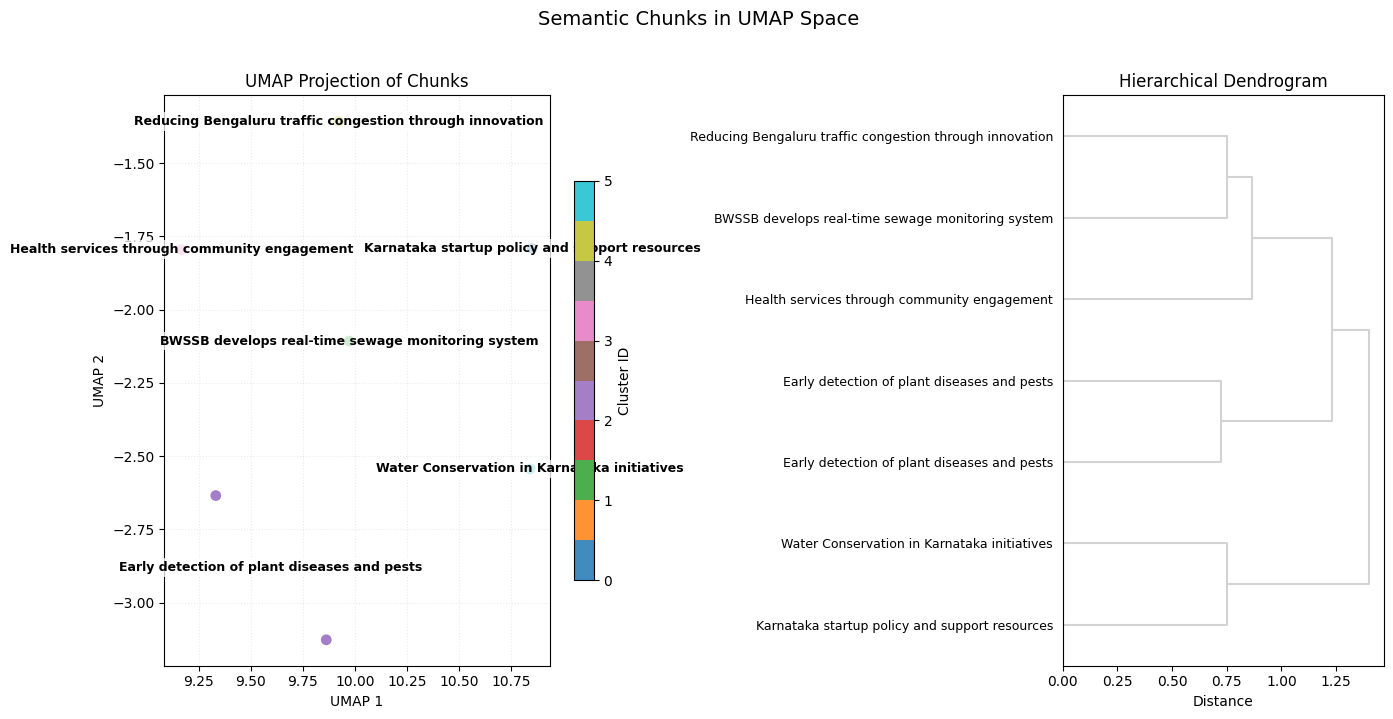

2026-03-12 09:23:28,286 - INFO - Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
2026-03-12 09:23:31,270 - INFO - 2 prompts are loaded, with the keys: ['query', 'text']
Generating embeddings: 100%|██████████| 19/19 [00:01<00:00, 12.93it/s]
/home/neeraj/Projects/pdf_to_markdown/pdf_to_md_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Found 12 semantic chunks.


2026-03-12 09:23:34,090 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-12 09:23:34,233 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-12 09:23:34,430 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-12 09:23:34,555 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-12 09:23:34,796 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
2026-03-12 09:23:34,965 - INFO - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


Generated Cluster Summaries:
  Cluster 0: Karnataka startup policy and support services
  Cluster 1: Government program for societal problem-solving innovations
  Cluster 2: Partnership with Karnataka Government Department
  Cluster 3: Karnataka State Mobility Grand Challenges announced
  Cluster 4: Karnataka's Urban Land Transport Directorate established
  Cluster 5: Karnataka Startup Eligibility Criteria Requirements


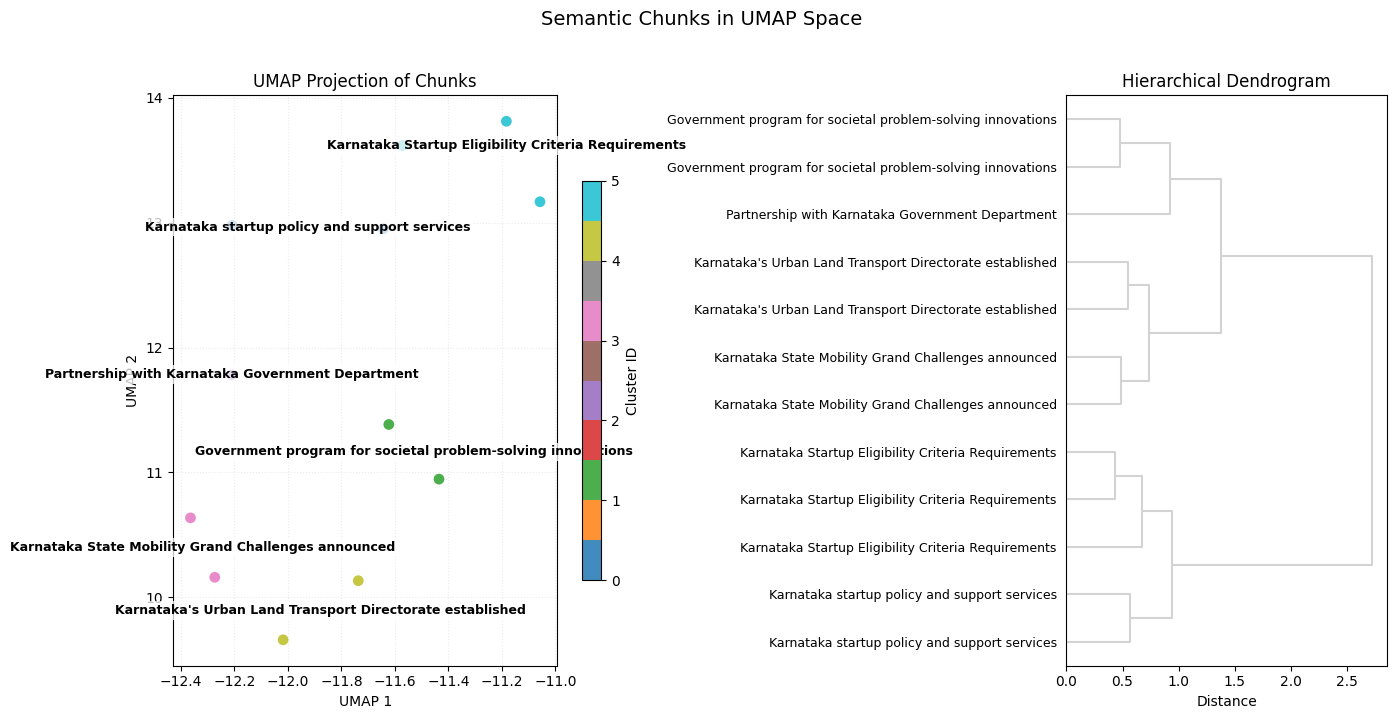

In [24]:
for document in documents:
    execute_semantic_clustering_chunking(document.text)